In [ ]:
!pip install numpy pandas scikit-learn xgboost imbalanced-learn scipy liac-arff matplotlib seaborn shap requests tabulate

  Preparing metadata (setup.py) ... done
  Created wheel for liac-arff: filename=liac_arff-2.5.0-py3-none-any.whl size=11717 sha256=3e5b2ed1668b93fabbfd6236f78dafc2c0157c82433571515fc71ae45cfac137
  Stored in directory: /root/.cache/pip/wheels/a9/ac/cf/c2919807a5c623926d217c0a18eb5b457e5c19d242c3b5963a
Successfully built liac-arff



Processing CM1.arff


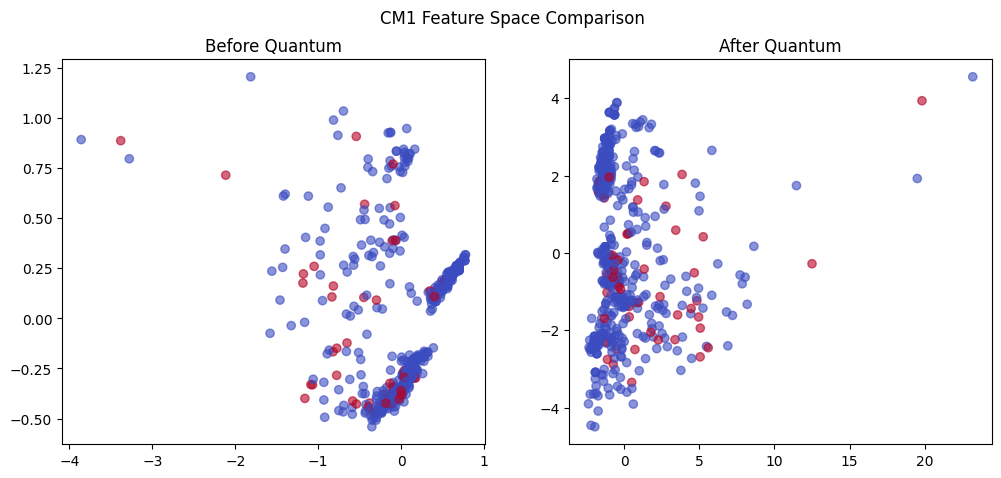


Processing JM1.arff


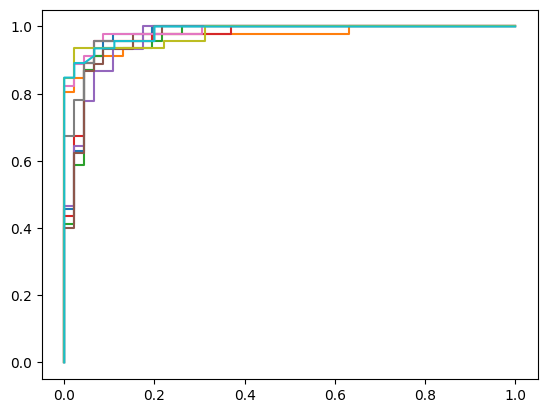

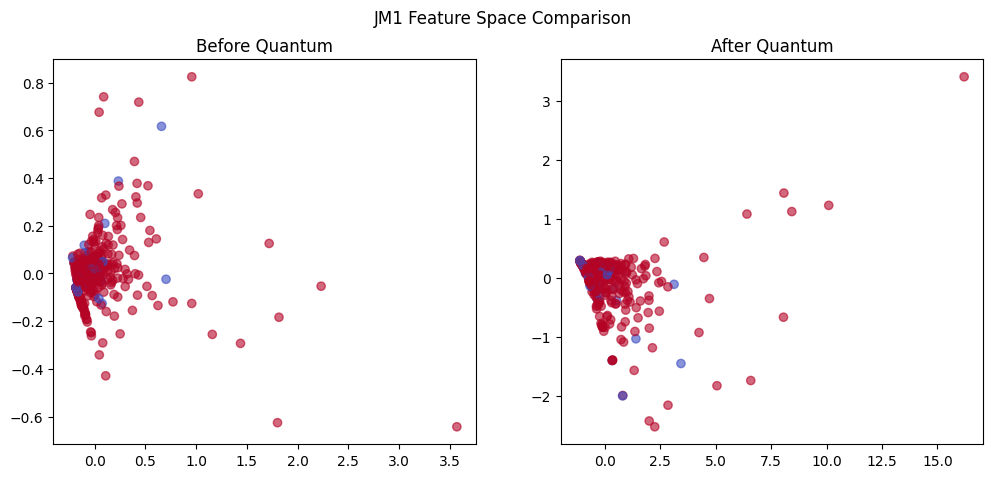


Processing KC1.arff


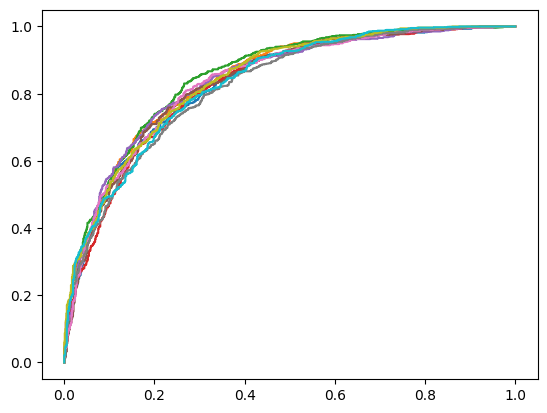

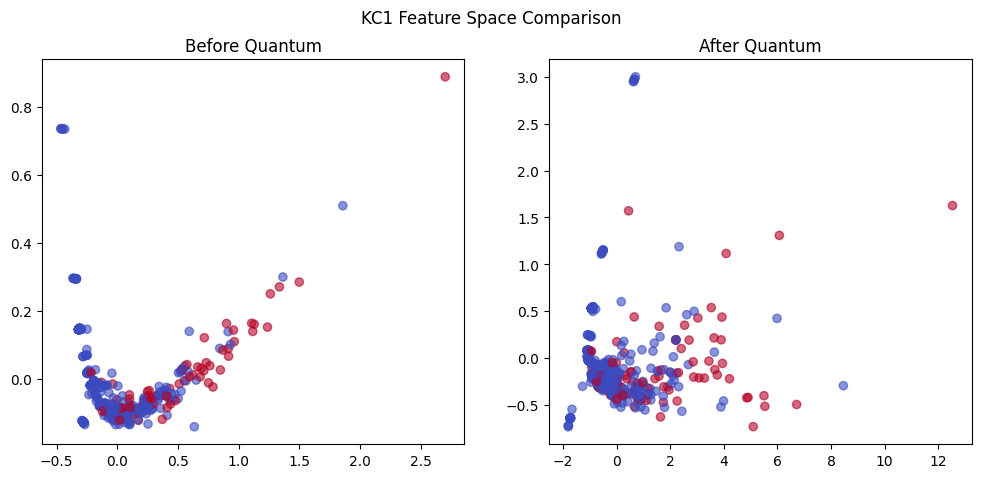


Processing MC1.arff


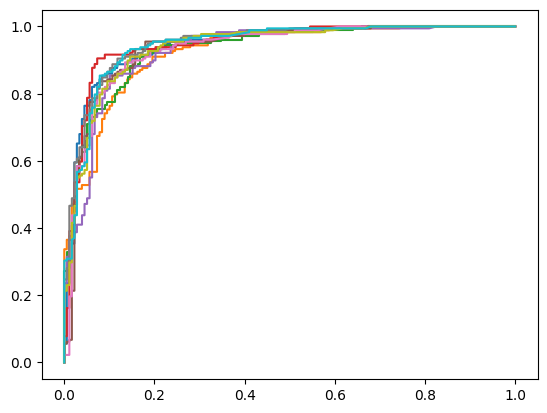

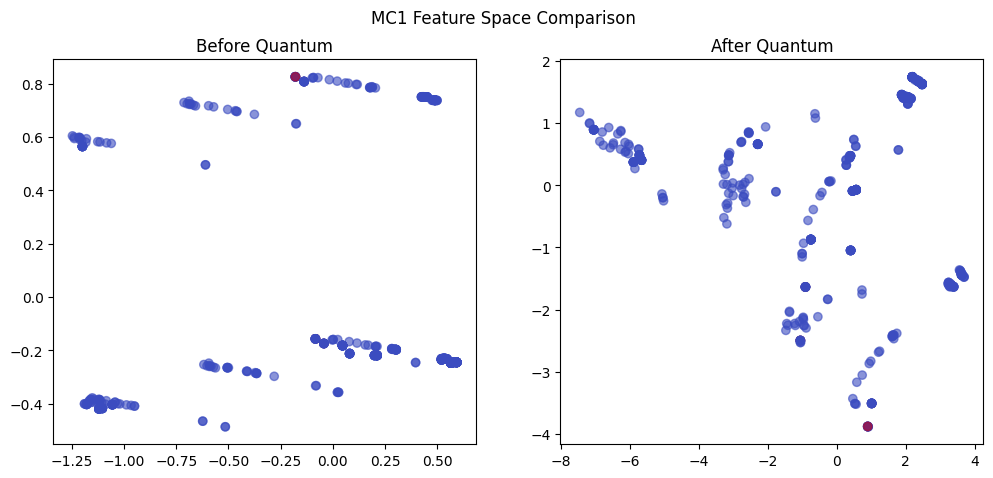


Processing MW1.arff


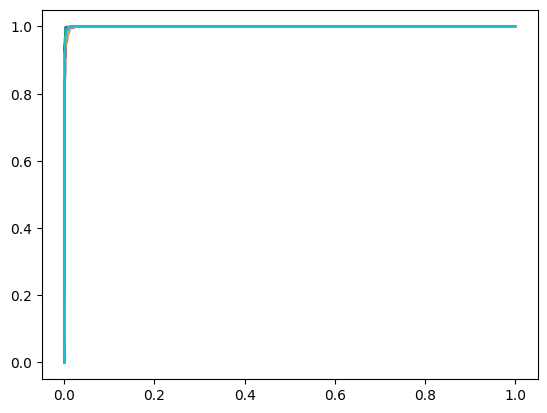

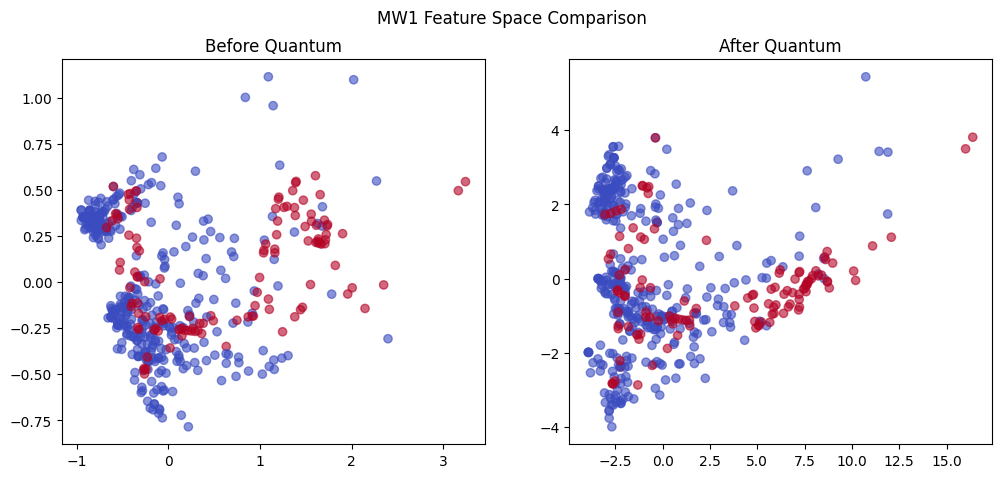


Processing PC1.arff


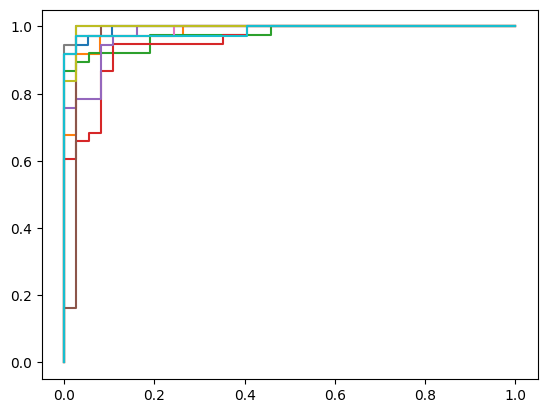

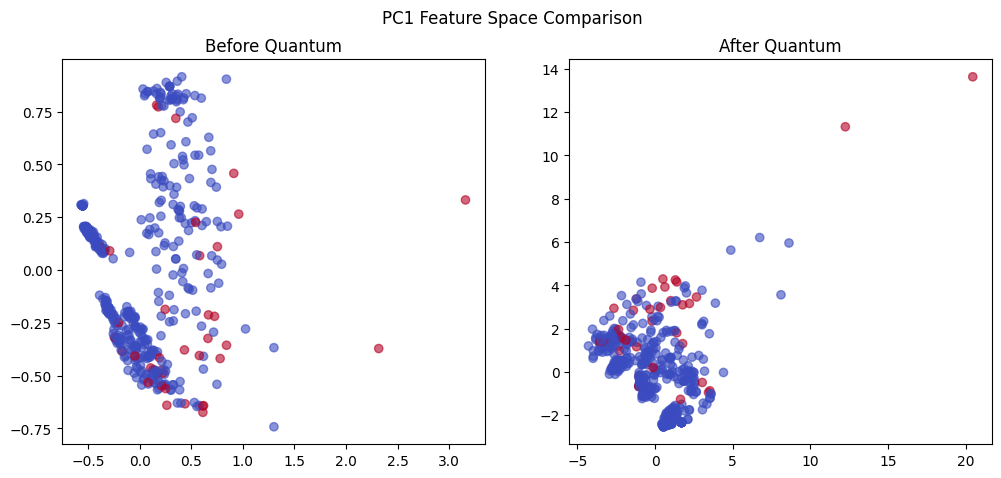

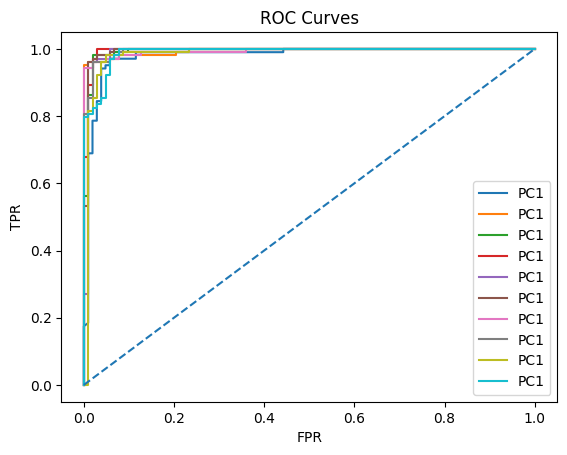


Mean Metrics:
                       Accuracy  Precision    Recall        F1       AUC  \
Dataset Model                                                              
CM1     RF             0.939823   0.921318  0.962899  0.941230  0.988488   
        SVM            0.795318   0.763285  0.857681  0.807061  0.898696   
        XGB_Classical  0.956223   0.943553  0.971401  0.956908  0.992549   
        XGB_Quantum    0.913557   0.886362  0.951932  0.917142  0.974208   
JM1     RF             0.890896   0.892505  0.888902  0.890665  0.950850   
        SVM            0.667730   0.701518  0.583869  0.637221  0.725632   
        XGB_Classical  0.862637   0.908121  0.806864  0.854457  0.932462   
        XGB_Quantum    0.754672   0.755717  0.752964  0.754254  0.835597   
KC1     RF             0.915545   0.902950  0.931514  0.916783  0.969806   
        SVM            0.744956   0.722675  0.795744  0.757174  0.821446   
        XGB_Classical  0.907692   0.916532  0.897295  0.906612  0.964031 

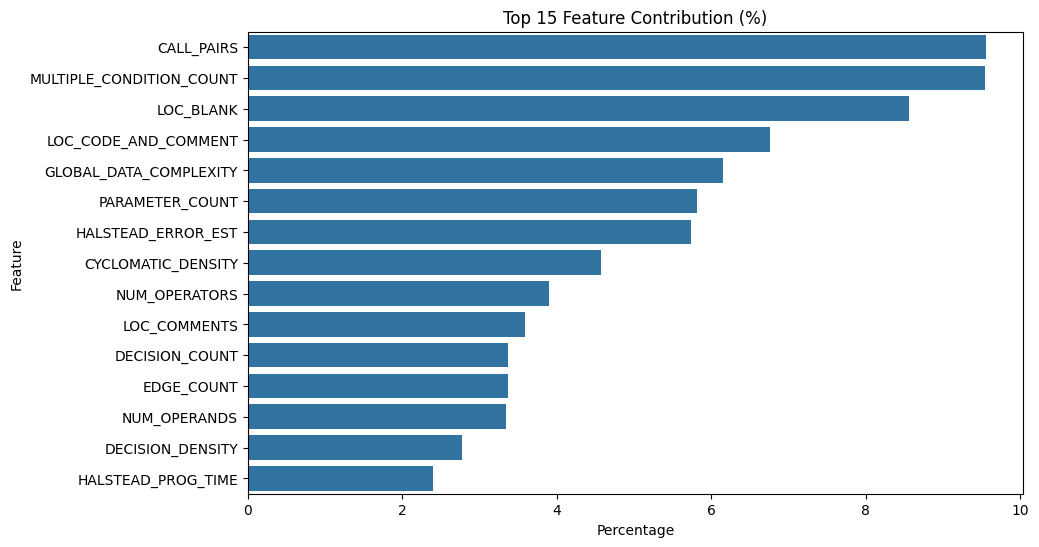


Wilcoxon Quantum vs Classical: WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(0.03125))

IEEE LaTeX Table:

\begin{tabular}{lrrrr}
\toprule
Model & RF & SVM & XGB_Classical & XGB_Quantum \\
Dataset &  &  &  &  \\
\midrule
CM1 & 0.9398 & 0.7953 & 0.9562 & 0.9136 \\
JM1 & 0.8909 & 0.6677 & 0.8626 & 0.7547 \\
KC1 & 0.9155 & 0.7450 & 0.9077 & 0.8740 \\
MC1 & 0.9974 & 0.9426 & 0.9977 & 0.9918 \\
MW1 & 0.9463 & 0.8400 & 0.9543 & 0.9302 \\
PC1 & 0.9714 & 0.8181 & 0.9714 & 0.9578 \\
\bottomrule
\end{tabular}



In [ ]:
import pandas as pd
import numpy as np
import arff
import requests
import io
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    roc_curve, matthews_corrcoef
)
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from scipy.stats import wilcoxon
from scipy.fft import fft
import xgboost as xgb

# ==========================================================
# DATASET CONFIG
# ==========================================================

base_url = "https://raw.githubusercontent.com/klainfo/NASADefectDataset/master/OriginalData/MDP/"
datasets = ["CM1.arff","JM1.arff","KC1.arff","MC1.arff","MW1.arff","PC1.arff"]

# ==========================================================
# LOAD FUNCTION
# ==========================================================

def load_arff_from_github(filename):
    url = base_url + filename
    response = requests.get(url)
    dataset = arff.load(io.StringIO(response.text))
    data = pd.DataFrame(dataset['data'])
    data.columns = [attr[0] for attr in dataset['attributes']]
    return data

# ==========================================================
# STORAGE
# ==========================================================

performance_results = []
metric_storage = []

# ==========================================================
# MAIN LOOP
# ==========================================================

for dataset in datasets:

    print(f"\nProcessing {dataset}")

    data = load_arff_from_github(dataset)
    target_col = data.columns[-1]

    # Target conversion
    try:
        data[target_col] = pd.to_numeric(data[target_col])
        data[target_col] = data[target_col].apply(lambda x: 1 if x > 0 else 0)
    except:
        data[target_col] = data[target_col].astype(str).str.lower()
        data[target_col] = data[target_col].apply(
            lambda x: 1 if x in ['true','yes','y','1'] else 0
        )

    y = data[target_col]
    if len(y.unique()) < 2:
        continue

    feature_names = data.drop(target_col, axis=1).columns

    X = data.drop(target_col, axis=1)
    X = X.apply(pd.to_numeric, errors='coerce')

    # Preprocessing
    X = SimpleImputer(strategy="median").fit_transform(X)
    X = MinMaxScaler().fit_transform(X)
    X = VarianceThreshold().fit_transform(X)
    X_res, y_res = SMOTE(random_state=42).fit_resample(X, y)

    # Quantum Transformation
    X_quantum = np.abs(fft(X_res))

    # ======================================================
    # Quantum Visualization (PCA)
    # ======================================================

    pca = PCA(n_components=2)
    X_pca_original = pca.fit_transform(X_res[:500])
    X_pca_quantum = pca.fit_transform(X_quantum[:500])

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.scatter(X_pca_original[:,0], X_pca_original[:,1],
                c=y_res[:500], cmap='coolwarm', alpha=0.6)
    plt.title("Before Quantum")

    plt.subplot(1,2,2)
    plt.scatter(X_pca_quantum[:,0], X_pca_quantum[:,1],
                c=y_res[:500], cmap='coolwarm', alpha=0.6)
    plt.title("After Quantum")

    plt.suptitle(dataset.replace(".arff","") + " Feature Space Comparison")
    plt.show()

    # ======================================================
    # MODEL EVALUATION (10-Fold CV)
    # ======================================================

    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    models = {
        "SVM": SVC(kernel="rbf", probability=True),
        "RF": RandomForestClassifier(n_estimators=200, random_state=42),
        "XGB_Classical": xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05),
        "XGB_Quantum": xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05)
    }

    model_scores = {name: [] for name in models}

    for train_idx, test_idx in skf.split(X_res, y_res):

        X_train_c, X_test_c = X_res[train_idx], X_res[test_idx]
        X_train_q, X_test_q = X_quantum[train_idx], X_quantum[test_idx]
        y_train, y_test = y_res.iloc[train_idx], y_res.iloc[test_idx]

        for name, model in models.items():

            if name == "XGB_Quantum":
                model.fit(X_train_q, y_train)
                y_pred = model.predict(X_test_q)
                y_prob = model.predict_proba(X_test_q)[:,1]
            else:
                model.fit(X_train_c, y_train)
                y_pred = model.predict(X_test_c)
                y_prob = model.predict_proba(X_test_c)[:,1]

            acc = accuracy_score(y_test, y_pred)
            prec = precision_score(y_test, y_pred)
            rec = recall_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred)
            auc = roc_auc_score(y_test, y_prob)
            mcc = matthews_corrcoef(y_test, y_pred)

            model_scores[name].append(acc)

            metric_storage.append([
                dataset.replace(".arff",""), name,
                acc, prec, rec, f1, auc, mcc
            ])

        fpr, tpr, _ = roc_curve(y_test, y_prob)
        plt.plot(fpr, tpr, label=dataset.replace(".arff",""))

    for name in model_scores:
        performance_results.append([
            dataset.replace(".arff",""),
            name,
            np.mean(model_scores[name])
        ])

# ==========================================================
# ROC CURVES
# ==========================================================

plt.plot([0,1],[0,1],'--')
plt.title("ROC Curves")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.show()

# ==========================================================
# METRICS TABLE
# ==========================================================

metrics_df = pd.DataFrame(
    metric_storage,
    columns=["Dataset","Model","Accuracy","Precision","Recall","F1","AUC","MCC"]
)

print("\nMean Metrics:")
print(metrics_df.groupby(["Dataset","Model"]).mean())

# ==========================================================
# SHAP EXPLAINABILITY (Classical XGB)
# ==========================================================

xgb_model = xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05)
xgb_model.fit(X_res, y_res)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_res)

mean_shap = np.abs(shap_values).mean(axis=0)

importance_df = pd.DataFrame({
    "Feature": feature_names[:len(mean_shap)],
    "Contribution": mean_shap
})

importance_df["Percentage"] = (
    importance_df["Contribution"] /
    importance_df["Contribution"].sum()
) * 100

importance_df = importance_df.sort_values(
    by="Percentage", ascending=False
)

print("\nTop Feature Contributions (%):")
print(importance_df.head(15))

plt.figure(figsize=(10,6))
sns.barplot(x="Percentage", y="Feature", data=importance_df.head(15))
plt.title("Top 15 Feature Contribution (%)")
plt.show()

# ==========================================================
# WILCOXON TEST
# ==========================================================

df_perf = pd.DataFrame(performance_results,
                       columns=["Dataset","Model","Accuracy"])

xgb_q = df_perf[df_perf["Model"]=="XGB_Quantum"]["Accuracy"].values
xgb_c = df_perf[df_perf["Model"]=="XGB_Classical"]["Accuracy"].values

print("\nWilcoxon Quantum vs Classical:",
      wilcoxon(xgb_q, xgb_c))

# ==========================================================
# IEEE LATEX TABLE
# ==========================================================

latex_table = df_perf.pivot(index="Dataset",
                            columns="Model",
                            values="Accuracy")

print("\nIEEE LaTeX Table:\n")
print(latex_table.to_latex(float_format="%.4f"))